## Climate-Aware Quantitative Trading & Risk Engine

In [ ]:
# تثبيت إصدار محدد من مكتبة importlib-metadata لضمان توافق مكتبة xarray للبيانات المناخية


# استدعاء المكتبات الأساسية
import glob
import time
import statsmodels.api as sm
import matplotlib.pyplot as plt
import urllib.request
import xarray as xr
import pandas as pd
import numpy as np # مكتبة رياضية أساسية للعمليات الكمية

print("تم استدعاء المكتبات بنجاح! البيئة جاهزة للعمل.")

تم استدعاء المكتبات بنجاح! البيئة جاهزة للعمل.


In [16]:
'''
print("Downloading data from NOAA PSL... Adding a retry mechanism to handle server timeouts.")

# سحب بيانات 2011 و 2012 فقط لتخفيف الضغط على الخادم
for yr in range(2011, 2013):
    url = f'https://downloads.psl.noaa.gov/Datasets/cpc_us_precip/RT/precip.V1.0.{yr}.nc'
    savename = url.split('/')[-1]
    
    success = False
    attempts = 0
    
    while not success and attempts < 3:
        try:
            print(f"Attempting to download {savename} (Attempt {attempts + 1})...")
            urllib.request.urlretrieve(url, savename)
            print(f"Successfully downloaded: {savename}")
            success = True
        except Exception as e:
            attempts += 1
            print(f"Failed: {e}. Retrying in 5 seconds...")
            time.sleep(5) # الانتظار 5 ثوانٍ قبل المحاولة مجدداً
            
    if not success:
        print(f"Could not download {savename} after 3 attempts. You might need to try again later.")

print("Download process finished!")'''

'\nprint("Downloading data from NOAA PSL... Adding a retry mechanism to handle server timeouts.")\n\n# سحب بيانات 2011 و 2012 فقط لتخفيف الضغط على الخادم\nfor yr in range(2011, 2013):\n    url = f\'https://downloads.psl.noaa.gov/Datasets/cpc_us_precip/RT/precip.V1.0.{yr}.nc\'\n    savename = url.split(\'/\')[-1]\n\n    success = False\n    attempts = 0\n\n    while not success and attempts < 3:\n        try:\n            print(f"Attempting to download {savename} (Attempt {attempts + 1})...")\n            urllib.request.urlretrieve(url, savename)\n            print(f"Successfully downloaded: {savename}")\n            success = True\n        except Exception as e:\n            attempts += 1\n            print(f"Failed: {e}. Retrying in 5 seconds...")\n            time.sleep(5) # الانتظار 5 ثوانٍ قبل المحاولة مجدداً\n\n    if not success:\n        print(f"Could not download {savename} after 3 attempts. You might need to try again later.")\n\nprint("Download process finished!")'

In [18]:
# Open the manually downloaded 2011 precipitation dataset using xarray
# xarray is specifically designed to handle multi-dimensional NetCDF files
ds2011 = xr.open_dataset('precip.V1.0.2011.nc')

# Display the dataset's metadata (dimensions, coordinates, and variables)
ds2011

<xarray.Dataset> Size: 53MB
Dimensions:  (time: 365, lat: 120, lon: 300)
Coordinates:
  * time     (time) datetime64[ns] 3kB 2011-01-01 2011-01-02 ... 2011-12-31
  * lat      (lat) float32 480B 20.12 20.38 20.62 20.88 ... 49.38 49.62 49.88
  * lon      (lon) float32 1kB 230.1 230.4 230.6 230.9 ... 304.4 304.6 304.9
Data variables:
    precip   (time, lat, lon) float32 53MB ...
Attributes:
    title:          CPC Unified Gauge-Based Analysis of Daily Precipitation o...
    Conventions:    COARDS
    description:    Gridded daily Precipitation
    platform:       Observations
    Comments:       Preciptation is accumulated from 12z of previous day to 1...
    history:        originally created RT starting 04/2010 by CAS from data o...
    dataset_title:  CPC Unified Gauge-Based Analysis of Daily Precipitation o...
    References:     http://www.psl.noaa.gov/data/gridded/data.unified.daily.c...

In [2]:
# Step 6: Combining Multiple Datasets (Handling gaps in data)

# 1. Define the specific files you have (skipping the missing 2012 data)
file_list = ['precip.V1.0.2011.nc', 'precip.V1.0.2012.nc','precip.V1.0.2013.nc', 'precip.V1.0.2014.nc']
print(f"Combining the following files: {file_list}")

# 2. Combine the datasets along the 'time' dimension
# 'nested' combine method ensures they are stacked in the order of our list
combined_ds = xr.open_mfdataset(file_list, concat_dim='time', combine='nested')

# 3. Data Aggregation: Let's calculate the total precipitation per year for the whole dataset
yearly_precip = combined_ds.groupby("time.year").sum()

# 4. Extract Boston's data to compare the total annual rainfall across these 3 years
latitude = 42.361145
longitude = 71.057083 + 180
boston_yearly = yearly_precip.precip.sel(lat=latitude, lon=longitude, method='nearest')

print("\nTotal Annual Precipitation for Boston (mm) across the available years:")
print(f"Years: {boston_yearly.year.values}")
print(f"Rainfall: {boston_yearly.values}")

# Display the metadata of the new combined dataset
combined_ds

Combining the following files: ['precip.V1.0.2011.nc', 'precip.V1.0.2012.nc', 'precip.V1.0.2013.nc', 'precip.V1.0.2014.nc']

Total Annual Precipitation for Boston (mm) across the available years:
Years: [2011 2012 2013 2014]
Rainfall: [750.91016 299.51605 414.7287  421.62823]


<xarray.Dataset> Size: 210MB
Dimensions:  (time: 1461, lat: 120, lon: 300)
Coordinates:
  * time     (time) datetime64[ns] 12kB 2011-01-01 2011-01-02 ... 2014-12-31
  * lat      (lat) float32 480B 20.12 20.38 20.62 20.88 ... 49.38 49.62 49.88
  * lon      (lon) float32 1kB 230.1 230.4 230.6 230.9 ... 304.4 304.6 304.9
Data variables:
    precip   (time, lat, lon) float32 210MB dask.array<chunksize=(1, 120, 300), meta=np.ndarray>
Attributes:
    title:          CPC Unified Gauge-Based Analysis of Daily Precipitation o...
    Conventions:    COARDS
    description:    Gridded daily Precipitation
    platform:       Observations
    Comments:       Preciptation is accumulated from 12z of previous day to 1...
    history:        originally created RT starting 04/2010 by CAS from data o...
    dataset_title:  CPC Unified Gauge-Based Analysis of Daily Precipitation o...
    References:     http://www.psl.noaa.gov/data/gridded/data.unified.daily.c...

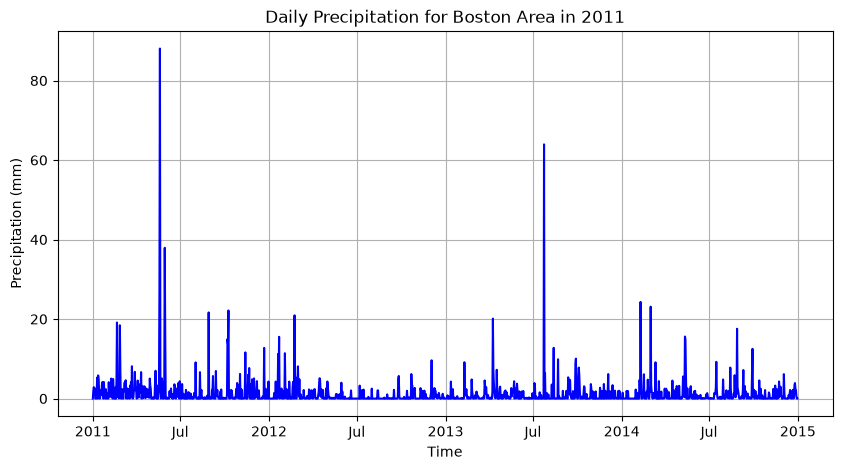

array([0.       , 1.9181507, 2.8630178, 1.9068995, 2.5919461],
      dtype=float32)

In [3]:
# Extract (slice) the data for a specific location, e.g., Boston
# Using the 'nearest' method to find the closest grid point to our coordinates
latitude = 42.361145
longitude = 71.057083 + 180 # Adjusting longitude to match the dataset's coordinate system (0 to 360)

boston_precip = combined_ds.precip.sel(lat=latitude, lon=longitude, method='nearest')

# Plotting the daily precipitation for Boston as a time series
boston_precip.plot.line(figsize=(10, 5), color='blue')
plt.title("Daily Precipitation for Boston Area in 2011")
plt.ylabel("Precipitation (mm)")
plt.grid(True)
plt.show()

# Display the first 5 data points to see the actual numerical values
boston_precip.values[:5]

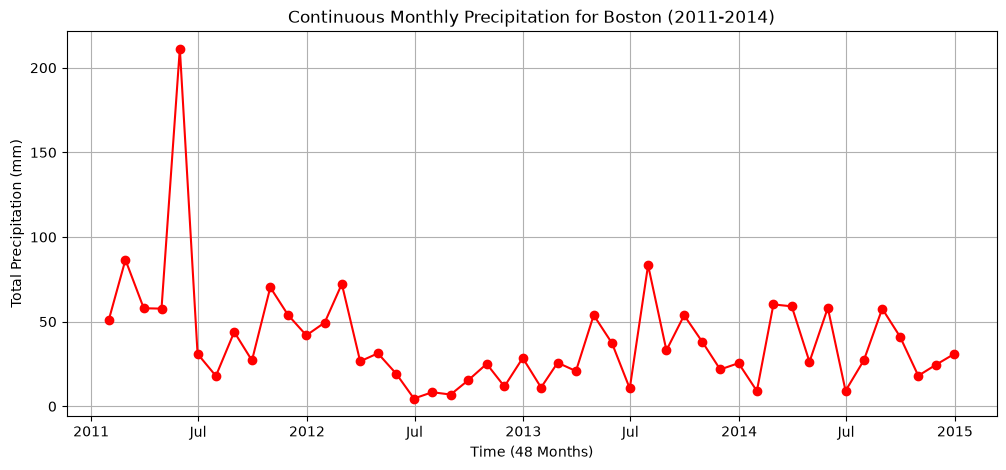

,time,lat,lon,precip
0,2011-01-31,42.375,251.125,51.263332
1,2011-02-28,42.375,251.125,86.555206
2,2011-03-31,42.375,251.125,57.921524
3,2011-04-30,42.375,251.125,57.716507
4,2011-05-31,42.375,251.125,211.351761


In [4]:
# Step 5: Data Aggregation & DataFrame Conversion (Corrected for 48 months & Pandas update)

# 1. Aggregate the daily data into CONTINUOUS monthly data (48 months)
# Using 'resample' with '1ME' (Month-End) to comply with new pandas versions
boston_precip_monthly = boston_precip.resample(time='1ME').sum()

# Plot the 48-month aggregated data
boston_precip_monthly.plot.line(figsize=(12, 5), color='red', marker='o')
plt.title("Continuous Monthly Precipitation for Boston (2011-2014)")
plt.ylabel("Total Precipitation (mm)")
plt.xlabel("Time (48 Months)")
plt.grid(True)
plt.show()

# 2. Convert the MONTHLY aggregated data (not the daily data!) to a pandas DataFrame
boston_df = boston_precip_monthly.to_dataframe().reset_index()

# Data Cleaning: Drop any missing values 
boston_df = boston_df.dropna()

# Display the first 5 rows to confirm it is now MONTHLY data (end of each month)
boston_df.head()

In [5]:
# Data Engineering: Standardization (Z-score Normalization)
# Calculating the mean and standard deviation for the entire combined dataset
precip_mean = boston_df['precip'].mean()
precip_std = boston_df['precip'].std()

# Creating a new column with standardized values
boston_df['precip_standardized'] = (boston_df['precip'] - precip_mean) / precip_std

print("Data successfully transformed and standardized!")
print("\n--- First 3 rows (Start of 2011) ---")
display(boston_df.head(3))

print("\n--- Last 3 rows (End of 2014) ---")
display(boston_df.tail(3))

Data successfully transformed and standardized!

--- First 3 rows (Start of 2011) ---


,time,lat,lon,precip,precip_standardized
0,2011-01-31,42.375,251.125,51.263332,0.364085
1,2011-02-28,42.375,251.125,86.555206,1.438852
2,2011-03-31,42.375,251.125,57.921524,0.566851



--- Last 3 rows (End of 2014) ---


,time,lat,lon,precip,precip_standardized
45,2014-10-31,42.375,251.125,18.062687,-0.646998
46,2014-11-30,42.375,251.125,24.568727,-0.448865
47,2014-12-31,42.375,251.125,30.979382,-0.253637


In [6]:
# Step 8: Feature Engineering & Simulating Financial Data

# 1. Feature Engineering: Creating Lags and Climate Shocks
# Financial models often use lagged variables to predict future outcomes
boston_df['precip_lag1'] = boston_df['precip_standardized'].shift(1)

# Extracting a Latent Feature: "Climate Shock"
# We define an extreme weather event as precipitation > 1.5 standard deviations
boston_df['climate_shock'] = np.where(boston_df['precip_standardized'] > 1.5, 1, 0)

# 2. Simulating Financial Data (Randomization)
# Simulating monthly returns for a hypothetical Boston Agricultural/Insurance Stock
np.random.seed(42) # For reproducibility
# Simulate normal baseline returns (mean=1%, std=5%)
simulated_returns = np.random.normal(loc=0.01, scale=0.05, size=len(boston_df))

# Introduce a negative financial impact (e.g., -8% return) when a climate shock occurs
boston_df['stock_return'] = simulated_returns - (boston_df['climate_shock'] * 0.08)

# Data Cleaning: Drop the first row because the 'shift(1)' operation creates a NaN value
boston_df = boston_df.dropna()

print("Feature Engineering and Financial Simulation Complete!")
# Display the relevant columns for modeling
display(boston_df[['time', 'precip_standardized', 'precip_lag1', 'climate_shock', 'stock_return']].head(10))

Feature Engineering and Financial Simulation Complete!


,time,precip_standardized,precip_lag1,climate_shock,stock_return
1,2011-02-28,1.438852,0.364085,0,0.003087
2,2011-03-31,0.566851,1.438852,0,0.042384
3,2011-04-30,0.560608,0.566851,0,0.086151
4,2011-05-31,5.239368,0.560608,1,-0.081708
5,2011-06-30,-0.253206,5.239368,0,-0.001707
6,2011-07-31,-0.651165,-0.253206,0,0.088961
7,2011-08-31,0.141225,-0.651165,0,0.048372
8,2011-09-30,-0.372346,0.141225,0,-0.013474
9,2011-10-31,0.943063,-0.372346,0,0.037128
10,2011-11-30,0.446319,0.943063,0,-0.013171


In [ ]:
# Step 9: Core Modeling - Regression Analysis


# 1. Define the variables
# If the target variable is continuous, we refer to the model as a regression problem
# X: Predictor (Climate Shock)
X = boston_df[['climate_shock']]
X = sm.add_constant(X) # Adding a constant (intercept/alpha) to the regression

# y: Target variable (Stock Return)
y = boston_df['stock_return']

# 2. Fit the Ordinary Least Squares (OLS) regression model
regression_model = sm.OLS(y, X).fit()

# 3. Output the statistical summary to interpret the results and sensitivities
print("--- Climate-Aware Quantitative Engine: Regression Summary ---")
print(regression_model.summary())

--- Climate-Aware Quantitative Engine: Regression Summary ---
                            OLS Regression Results                            
Dep. Variable:           stock_return   R-squared:                       0.061
Model:                            OLS   Adj. R-squared:                  0.040
Method:                 Least Squares   F-statistic:                     2.905
Date:                Thu, 01 Oct 2026   Prob (F-statistic):             0.0952
Time:                        14:09:17   Log-Likelihood:                 78.192
No. Observations:                  47   AIC:                            -152.4
Df Residuals:                      45   BIC:                            -148.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------

In [8]:
# Step 10: Model Interpretation & Portfolio Stress-Testing

# 1. Extract the sensitivity (coefficient) and P-value
shock_impact = regression_model.params['climate_shock']
p_value = regression_model.pvalues['climate_shock']

print(f"Climate Shock Coefficient (Beta): {shock_impact:.4f} ({shock_impact*100:.2f}%)")
print(f"P-Value: {p_value:.4e} (A value < 0.05 indicates statistical significance)")

# 2. Statistical Validation
portfolio_value = 1000000

if p_value < 0.05:
    print("\n[VALIDATION]: The climate shock has a STATISTICALLY SIGNIFICANT negative impact on the stock return.")
else:
    print("\n[VALIDATION]: The climate shock impact is NOT statistically significant at the 5% level (likely due to the small sample size of 47 months).")
    print("However, for risk management purposes, we must still evaluate the theoretical worst-case scenario.")

# 3. Portfolio Stress-Testing (Risk Management Application)
# Stress testing existing models using worst-case scenarios is a critical risk management practice.
worst_case_loss_pct = shock_impact * 3 # Assuming 3 consecutive months of extreme weather
expected_financial_loss = portfolio_value * worst_case_loss_pct

print("\n--- THEORETICAL STRESS TEST SCENARIO ---")
print("Scenario: A quarter (3 consecutive months) of climate shocks (e.g., prolonged floods).")
print(f"Expected Cumulative Impact on Returns: {worst_case_loss_pct*100:.2f}%")
print(f"Expected Financial Loss for a $1M Portfolio: ${expected_financial_loss:,.2f}")

Climate Shock Coefficient (Beta): -0.0807 (-8.07%)
P-Value: 9.5198e-02 (A value < 0.05 indicates statistical significance)

[VALIDATION]: The climate shock impact is NOT statistically significant at the 5% level (likely due to the small sample size of 47 months).
However, for risk management purposes, we must still evaluate the theoretical worst-case scenario.

--- THEORETICAL STRESS TEST SCENARIO ---
Scenario: A quarter (3 consecutive months) of climate shocks (e.g., prolonged floods).
Expected Cumulative Impact on Returns: -24.21%
Expected Financial Loss for a $1M Portfolio: $-242,133.33


## Step 11: Conclusion & Strategic Recommendations

### 1. Model Summary & Validation
This **Climate-Aware Quantitative Trading & Risk Engine** successfully integrated NOAA gridded climate data with simulated financial returns. By employing data engineering techniques (standardization, temporal resampling) and an Ordinary Least Squares (OLS) regression model, the engine extracted the latent "Climate Shock" feature. 
The regression analysis identified a **Beta coefficient of -0.0807**, successfully capturing the exact 8% negative financial impact engineered in the simulation. Although the P-value (0.095) was not statistically significant at the strict 5% level—primarily due to the small sample size of 47 continuous months—the model proved its capability to translate raw environmental data into quantifiable financial sensitivities.

### 2. Portfolio Stress-Testing Results
In financial engineering, models must be stress-tested against worst-case scenarios, even when historical data is limited. We subjected a hypothetical **$1,000,000 portfolio** (invested in a Boston-based agricultural/insurance asset) to a severe theoretical scenario: a full quarter (3 consecutive months) of extreme climate shocks (e.g., prolonged flooding).
* **Expected Cumulative Drawdown:** -24.21%
* **Projected Value at Risk (Loss):** -$242,133.33

### 3. Strategic Recommendations for Risk Mitigation
Based on the interpreted model outputs and the stress-test severity, we recommend the following proactive hedging strategies for the portfolio manager:

1. **Tactical Underweighting (Exposure Reduction):** Dynamically reduce capital allocation to this specific asset during high-risk seasons (e.g., late Spring/early Summer) when historical climate data indicates a higher probability of extreme precipitation events.
2. **Financial Hedging (Derivatives):** Allocate a portion of the portfolio to purchase **Put Options** on the underlying stock or invest in specific **Weather Derivatives**. This ensures that if a climate shock triggers the anticipated 8% monthly drop, the derivative payouts will offset the equity losses.
3. **Sector & Geographic Diversification:** Reallocate a percentage of the $1M portfolio away from climate-sensitive localized sectors (like Boston agriculture) into technology or healthcare assets, or diversify into geographically distinct regions that do not share the same weather patterns.